##### ARTI 560 - Computer Vision  
## Image Classification using Convolutional Neural Networks (CNNs) - Exercise 

### Objective

In this exercise, you will:

1. **Load the Fashion MNIST dataset** from the [Keras dataset](https://keras.io/api/datasets/) website.
2. **Preprocess the data** for training.
3. **Build your own CNN architecture** and evaluate the model.

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load Fashion MNIST data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Number of unique classes
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of classes: 10


In [3]:
# Define class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


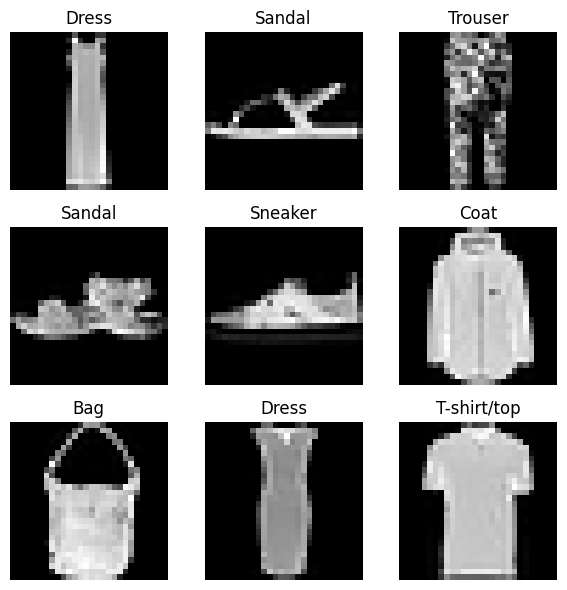

In [4]:
# Plot a 3x3 grid of random images from the dataset with their labels
plt.figure(figsize=(6,6))

for i in range(9):
    idx = np.random.randint(0, len(x_train))
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(class_names[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()


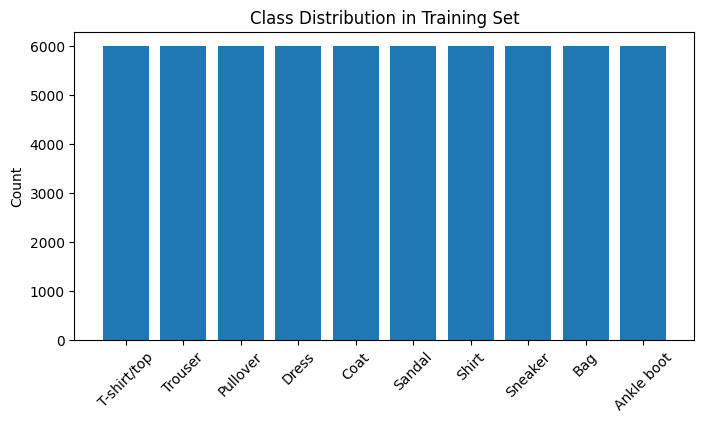

In [5]:
# Count occurrences of each class in the training set
unique, counts = np.unique(y_train, return_counts=True)

# Plot the class distribution
plt.figure(figsize=(8,4))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution in Training Set")
plt.ylabel("Count")
plt.show()


### Build your Image Classification Model
Note: Don't use one hot encoding and use sparse_categorical_crossentropy for loss

In [6]:
# Import libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Normalize pixel values for x_train and x_test
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension (CNN expects 4D input)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Build a CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # IMPORTANT: no one-hot
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


c:\Users\noraa\anaconda3\envs\cv_lab\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.8109 - loss: 0.5201 - val_accuracy: 0.8708 - val_loss: 0.3629
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8779 - loss: 0.3373 - val_accuracy: 0.8839 - val_loss: 0.3146
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8953 - loss: 0.2870 - val_accuracy: 0.8878 - val_loss: 0.3153
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9070 - loss: 0.2560 - val_accuracy: 0.8939 - val_loss: 0.2866
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9153 - loss: 0.2293 - val_accuracy: 0.8952 - val_loss: 0.2974
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9225 - loss: 0.2096 - val_accuracy: 0.9028 - val_loss: 0.2705
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9295 - loss: 0.1895 - val_accuracy: 0.9084 - val_loss: 0.2610
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9358 - loss: 0.1727 - 

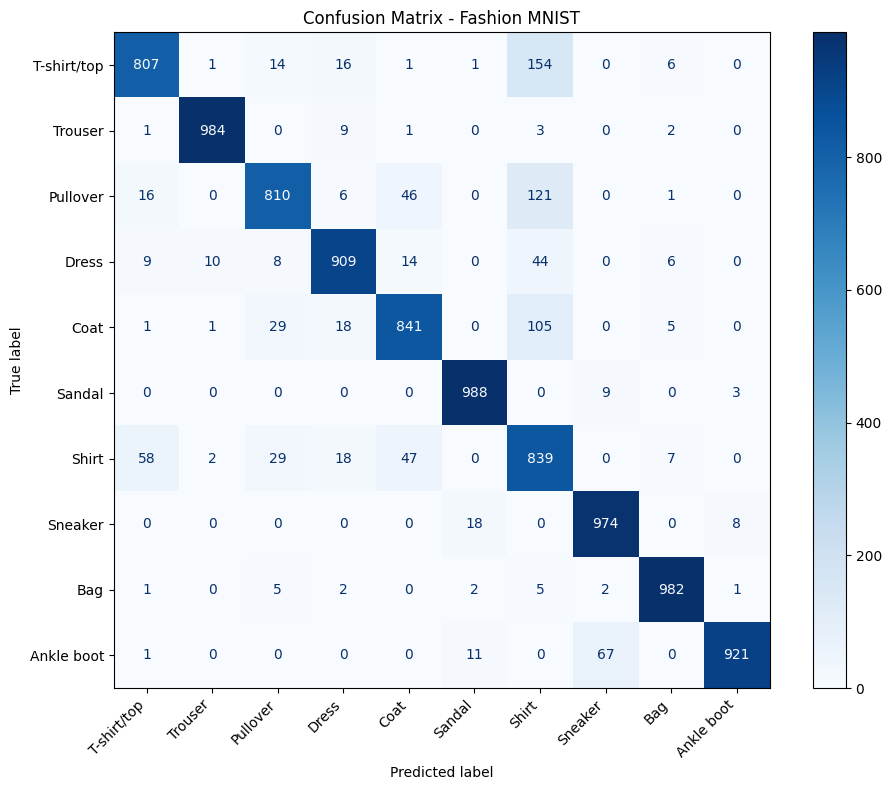

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.81      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.91      0.81      0.85      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.89      0.84      0.86      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.66      0.84      0.74      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.99      0.92      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [7]:
# Confusion Matrix + Classification Report

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict class probabilities, then convert to class indices
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix - Fashion MNIST")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# (Optional) Text report (precision/recall/F1 per class)
print(classification_report(y_test, y_pred, target_names=class_names))
